In [13]:
%run common_setup.ipynb

### This class constructs the pageRank for sources linked by citation counts

-  build the edge list of journal (citer) -> journal (cited)  
-  construct an iGraph from the edge list  
-  run pageRank  
-  for each author, calculate the number of ciations and the number of citations weighted by the pageRank of the citing journal



In [14]:
class ExtractEdgeLists(SetUp):
  
    def __init__(self):
        super().__init__()
        return
  
    def extract_source_edge_list(self):
        print('extract source edge list')

        sql = """
            CREATE OR REPLACE TABLE project.source_edge_list AS
            (
            -- BUILD SOURCE EDGE LISTS FOR PAGERANK
            --**************************************
            WITH
            -->> SELECT source/works in the set
            --**************************************************************************
            sources_CTE AS
                (SELECT DISTINCT id AS work_id,
                        "primary_location.source".id AS source_id,
                    FROM project.raw
                ),
            -->> SELECT citer_cited pairs in the set
            --**************************************  
            citer_cited_CTE AS
                (SELECT *
                FROM
                    (SELECT DISTINCT id AS citer_id,
                        unnest(referenced_works) AS cited_id
                    FROM project.raw
                    )
                WHERE cited_id in (SELECT id FROM project.raw)  
                    -- AND citer_id = 'https://openalex.org/W1000079159' AND cited_id = 'https://openalex.org/W1536446786'
                ),
            -->> SELECT citer works details
            --*****************************
            citer_sources_CTE AS
                (SELECT work_id AS citer_id,
                        source_id AS source_id_citer, 
                        cited_id,
                FROM citer_cited_CTE
                LEFT JOIN sources_CTE
                ON citer_id = work_id
                ),
            
            -->> SELECT citer and cited sources details
            --*****************************
            citer_cited_sources_CTE AS
                (SELECT citer_id,
                        source_id_citer,
                        cited_id,
                        w.source_id AS source_id_cited,
                FROM citer_sources_CTE c
                INNER JOIN sources_CTE w
                ON c.cited_id = w.work_id
                WHERE w.work_id NOT NULL
                ), 
            -->> CONSTRUCT source citation edge list 
            --**************************************
            source_edge_list_CTE AS
                (SELECT DISTINCT source_id_citer AS citer_unit,
                        source_id_cited AS cited_unit,
                        count(citer_id) AS weights,
                FROM citer_cited_sources_CTE
                WHERE source_id_citer != source_id_cited
                GROUP BY ALL
                ) 
            
            -- TESTS
            SELECT *
            FROM source_edge_list_CTE
            )
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM project.source_edge_list ORDER BY weights DESC").show()
        self.db.sql("SELECT sum(weights) AS sum_of_source_weights FROM project.source_edge_list").show()
        return
  
    def extract_institution_edge_list(self):
        sql = """
            CREATE OR REPLACE TABLE project.institution_edge_list AS
            (
            -- BUILD INSTITUTION EDGE LISTS FOR PAGERANK
            --**************************************
            WITH
            -- -->> SELECT works/institutions in the set
            -- --*************************************
            institutions_CTE AS
                (SELECT DISTINCT work_id,
                        unnest(authorship.institutions).id AS institution_id
                FROM (SELECT DISTINCT id AS work_id,
                                unnest(authorships) AS authorship
                        FROM project.raw
                        )
                ),
            -->> SELECT FILTERED works/institutions in the set 
            -->> (drop institutions with fewer than XX publications in the period)
            --*************************************
            filtered_institutions_CTE AS
                (SELECT i.work_id,
                        i.institution_id
                FROM institutions_CTE i
                INNER JOIN
                    (SELECT institution_id,
                            count(work_id) AS work_counts
                    FROM institutions_CTE
                    GROUP BY ALL
                    ) sub
                USING (institution_id)
                -- WHERE sub.work_counts > 10*15
                ),
            -->> SELECT citer_cited pairs in the set
            --**************************************  
            citer_cited_CTE AS
                (SELECT *
                FROM
                    (SELECT id AS citer_id,
                            unnest(referenced_works) AS cited_id
                    FROM project.raw
                    ) 
                WHERE cited_id in (SELECT work_id FROM institutions_CTE)
                    -- AND citer_id = 'https://openalex.org/W1000357097' AND cited_id = 'https://openalex.org/W2079631208'
                ),
            -->> SELECT citer institutions
            --*****************************
            citer_institutions_CTE AS
                (SELECT citer_id,
                        institution_id AS citer_institution_id, 
                        cited_id,
                        count(DISTINCT citer_institution_id) OVER (PARTITION BY citer_id, cited_id) AS citer_institutions_count
                FROM citer_cited_CTE
                INNER JOIN filtered_institutions_CTE
                ON citer_id = work_id
                ),
            
            -->> SELECT cited instutions
            --*****************************
            cited_institutions_CTE AS
                (SELECT DISTINCT citer_id,
                        cited_id,
                        w.institution_id AS cited_institution_id,
                        count(DISTINCT cited_institution_id) OVER (PARTITION BY citer_id, cited_id) AS cited_institutions_count
                FROM citer_cited_CTE c
                INNER JOIN filtered_institutions_CTE w
                ON c.cited_id = w.work_id
                ), 
            -->> JOIN citer and cited institutions 
            --**************************************
            citer_cited_institutions_CTE AS
                (SELECT r.citer_id,
                        r.citer_institution_id,
                        r.citer_institutions_count,
                        d.cited_id,
                        d.cited_institution_id,
                        d.cited_institutions_count
                FROM citer_institutions_CTE r
                INNER JOIN cited_institutions_CTE d
                ON r.citer_id = d.citer_id AND r.cited_id = d.cited_id
                ),
            
            -->> CONSTRUCT source citation edge list 
            --**************************************
            institution_edge_list_CTE AS
                (SELECT DISTINCT citer_institution_id AS citer_unit,
                        cited_institution_id AS cited_unit,
                        sum(1.0/(citer_institutions_count * cited_institutions_count)) AS weights
                FROM citer_cited_institutions_CTE
                WHERE citer_institution_id != cited_institution_id
                GROUP BY ALL
                ) 

            -- TEST
            SELECT *
            FROM institution_edge_list_CTE
            )
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM project.institution_edge_list ORDER BY weights DESC").show()
        self.db.sql("SELECT sum(weights) AS sum_of_institution_weights FROM project.institution_edge_list").show()
        return
    
    def both_edge_list(self):
        self.db.sql("SELECT sum(weights) AS source_weight_sum FROM project.source_edge_list").show()
        self.db.sql("SELECT sum(weights) AS institution_weight_sum FROM project.institution_edge_list").show()
        sql = """
            CREATE OR REPLACE TABLE project.both_edge_list AS
                (SELECT * FROM project.institution_edge_list
                UNION
                SELECT * FROM project.source_edge_list
                )
            """
        self.db.sql(sql)
        return
    
    def article_vector(self):
        print('article vector')
        sql = """
            CREATE OR REPLACE TABLE project.article_vectors AS  
            SELECT * FROM
            -- ARTICLE VECTORS FOR SOURCES
            -- ===========================
            (WITH
                source_works_count_CTE AS
                (SELECT DISTINCT 
                        count(DISTINCT id) OVER (PARTITION BY "primary_location.source".id) AS unit_works_count,
                        count(DISTINCT id) OVER () AS total_works,
                        "primary_location.source".id AS unit_id,
                    FROM project.raw
                )
            
            SELECT unit_works_count/total_works AS article_vector,
                    unit_works_count,
                    unit_id,
                    total_works
                FROM source_works_count_CTE)
            UNION
            -- ARTICLE VECTORS FOR INSTITUTIONS
            -- ===========================
            (WITH
            institutions_count_CTE AS
                (SELECT count(DISTINCT work_id) OVER () AS total_works,
                        count(DISTINCT work_id) OVER (PARTITION BY institution_id) AS unit_works_count,
                        institution_id AS unit_id,
                FROM project.authorships
                )

            SELECT DISTINCT
                    unit_works_count/total_works AS article_vector,
                    unit_works_count,
                    unit_id,
                    total_works
            FROM institutions_count_CTE)
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM project.article_vectors").show()
        return

In [15]:
class PageRank(SetUp):

    def __init__(self):
        super().__init__()
        return

    def vertex_labels(self):

        sql = """
            -- VERTEX LABLES
            -- ========================================
            WITH 
            vertex_labler_CTE AS
                (SELECT source_id,
                        source_name,
                        unnest(authorship.institutions).id AS institution_id,
                        unnest(authorship.institutions).display_name AS institution_name,
                FROM
                    (SELECT id AS work_id,
                        "primary_location.source".id AS source_id,
                        "primary_location.source".display_name AS source_name,
                        unnest(authorships) AS authorship,
                    FROM project.raw
                    )
                )

            SELECT source_id AS unit_id,
                    source_name AS unit_name,
            FROM vertex_labler_CTE
            UNION
            (SELECT institution_id AS unit_id,
                    institution_name AS unit_name,
                FROM vertex_labler_CTE)
            """
        df = self.db.sql(sql).df()
        print(df.head())
        self.vertex_labels = dict(zip(df.unit_id, df.unit_name))
        return
    
    def article_vectors(self):
        self.article_vector = self.db.sql("SELECT * FROM project.article_vectors").df()
        self.av_dd = dict(zip(self.article_vector.unit_id, self.article_vector.article_vector))
        return

    def _extract_edge_list(self):
        kind = self.kind
        df = self.db.sql(f"SELECT citer_unit, cited_unit, weights FROM project.{kind}_edge_list").df().\
            sort_values('weights', ascending=False).reset_index(drop=True)
        print(f'{kind = } {df.weights.max() = }')
        return df
    
    def construct_graph(self, kind=None):
        self.kind = kind
        df_edges = self._extract_edge_list()    
        vertices = set(df_edges.citer_unit.tolist() + df_edges.cited_unit.tolist())
        vs = pd.DataFrame(data=list(vertices), columns=['id'])
        vs['label'] = [self.vertex_labels.get(id) for id in vs.id]
        print(f'{vs['id'].nunique() = } {df_edges.shape = }\n{df_edges.head()}\n{df_edges.tail()}')
        print(f'GRAPH NODES - Vertex count for {self.kind = } {vs.shape = }\n{vs.head()}')
        self.g = ig.Graph.DataFrame(df_edges, directed=True, use_vids=False, vertices=vs)
        summary = ig.summary(self.g, verbosity=1, width=256, edge_list_format='auto', max_rows=2, print_graph_attributes=True, 
                                          print_vertex_attributes=True, print_edge_attributes=True, full=False)
        print(f'*** SUMMARY OF self.g\n{summary}')
        return
    
    def run_pagerank(self):
        print('pageRank')
        damping = 0.5  # if self.kind == 'both' else 0.85
        print(f'>> RUN pagerank with {damping = } for {self.kind = }')
        ranks = self.g.pagerank(damping=damping)
        print(f'>> CHECK pageRank  - should sum to unity {sum(ranks) = } then scaled to a sum of 100 as in "eigenfactor" score')
        sum_ranks = sum(ranks)
        scaled_ranks = [100.0 * r / sum_ranks for r in ranks]
        pagerank = pd.DataFrame({
                                'pageRank': scaled_ranks,
                                'citer': self.g.vs['name'],
                                'label': self.g.vs['label'],
                                'in_degree': self.g.strength(mode='in', weights='weights'),
                                'out_degree': self.g.strength(mode='out', weights='weights')
                                }).sort_values('pageRank', ascending=False)
        pagerank['influence'] = [pr/self.av_dd.get(lab, 0.01)/100.0 for lab, pr in zip(pagerank.citer, pagerank.pageRank)]
        pagerank['article_vector'] = [self.av_dd.get(lab, 0.01)*100.0 for lab in pagerank.citer]
        self.db.sql(f"CREATE OR REPLACE TABLE project.pagerank_{self.kind} AS SELECT * FROM pagerank")
        return
    
    def report_pagerank(self):
        kind = self.kind
        for measure in ['pageRank', 'influence']:
            df = (
                self.db.sql(f"SELECT * FROM project.pagerank_{kind}")
                .df()
                .sort_values(f'{measure}', ascending=False)
                .reset_index(drop=True)
            )
            print(f"Pagerank for {measure!r} {kind!r}: {df.shape}\n{df.head()}\n{df.tail()}")
            print(f"Sum of out_degrees: {df['out_degree'].sum()}")
            print(f"Sum of pageranks: {df['pageRank'].sum()}")
            sum_weights = self.db.sql(f"SELECT SUM(weights) AS total_weights FROM project.{kind}_edge_list").df().iloc[0, 0]
            print(f"Sum of edge weights: {sum_weights}")
        return

In [16]:
class Plotters(SetUp):

    def __init__(self):
        super().__init__()
        return

    def plot_pagerank(self):
        hold = []
        for kind in ['source', 'institution']: #, 'both']:
            temp = self.db.sql(f"SELECT * FROM project.pagerank_{kind}").df().sort_values('pageRank', ascending=True).reset_index(drop=True).reset_index(drop=False)
            temp['panel'] = kind
            hold.append(temp)
            print(f'{temp.shape = } {temp.pageRank.max() = } {temp.pageRank.min() = }\n{temp[temp.isnull().any(axis=1)]}')
            print(f'{temp.sort_values('out_degree', ascending=False).head()}')
        df = pd.concat(hold, axis=0)
        df = df.melt(id_vars=['out_degree', 'panel', 'label'], value_vars=['pageRank', 'influence'], var_name='measure', value_name='Value')
        print(f'{df.shape = }\n{df.head()}\n{df.info()}')
        grouped = df.groupby(['panel', 'measure']).agg({'out_degree': ['min', 'max'], 'Value': ['min', 'max']})
        print(grouped)
        g = sns.relplot(df, x='out_degree', y='Value', col='panel', row='measure', kind='scatter', facet_kws={'sharey': False, 'sharex':False}, 
                        size=0.1, color='black', alpha=0.2)
        # Set different y-axis scales for upper and lower panels
        for row_i, measure in enumerate(g.row_names):
            for col_j, panel in enumerate(g.col_names):
                ax = g.axes[row_i, col_j]
                frame = (col_j, row_i)
                for v in ['Value', 'out_degree']:
                    point_x, point_y, point_label = self.labeler(df=df, case=frame, value=v)
                    print(point_x, point_y, point_label)
                    ax.text(point_x, point_y, point_label, ha='center', va='center', fontsize=6, color='brown')
                    ax.plot(point_x, point_y, 'bX')
                match frame:
                    case (0, 0):
                        x0, x1 = (1e0, 1e5)
                        y0, y1 = (1e-2, 1e0)
                    case (0, 1):
                        x0, x1 = (1e0, 1e5)
                        y0, y1 = (1e-1, 1e2)
                    case (1, 0):
                        x0, x1 = (1e0, 1e5)
                        y0, y1 = (1e-3, 1e0)
                    case (1, 1):
                        x0, x1 = (1e0, 1e5)
                        y0, y1 = (1e-2, 1e2)
                ax.set_xlim((x0, x1))
                ax.set_ylim((y0, y1))
                ax.set_xscale('log')
                ax.set_yscale('log')
        plt.suptitle("PageRank and Influence versus out-degree (i.e. emitted citations)", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig("../my_plot.png", dpi=300)
        plt.show()
        return
    
    def labeler(self, df=None, case=None, value=None):
        c1, c2 = case
        print(c1, c2)
        measure = 'pageRank' if c2 == 0 else 'influence'
        panel = 'source' if c1 == 0 else 'institution'
        print(measure, panel)
        df = df.sort_values(value, ascending=False).drop_duplicates(subset=['panel', 'measure'])
        print(df.head())
        for row in df.itertuples():
            if row.panel == panel and row.measure == measure:
                return row.out_degree, row.Value, row.label
        return 




In [17]:
def main():

    exel = ExtractEdgeLists()
    exel.extract_source_edge_list()
    exel.extract_institution_edge_list()
    exel.both_edge_list()
    exel.article_vector()
    exel.db.close()

    pr = PageRank()
    pr.vertex_labels()
    pr.article_vectors()
    for kind in ['source', 'institution']:  #, 'both']:
        pr.construct_graph(kind=kind)
        pr.run_pagerank()
        pr.report_pagerank()
    pr.db.close()

    p = Plotters()
    p.plot_pagerank()
    p.db.close()

┌──────────┬─────────┬──────────────────────┬──────────────────────┬───────────────────────────────────────┬───────────┐
│ database │ schema  │         name         │     column_names     │             column_types              │ temporary │
│ varchar  │ varchar │       varchar        │      varchar[]       │               varchar[]               │  boolean  │
├──────────┼─────────┼──────────────────────┼──────────────────────┼───────────────────────────────────────┼───────────┤
│ authors  │ main    │ authors              │ [id, orcid, displa…  │ [VARCHAR, VARCHAR, VARCHAR, VARCHAR…  │ false     │
│ authors  │ main    │ trace                │ [id, works_count, …  │ [VARCHAR, BIGINT, BIGINT, BIGINT, D…  │ false     │
│ backup   │ main    │ authors              │ [author_id, orcid,…  │ [VARCHAR, VARCHAR, VARCHAR, VARCHAR…  │ false     │
│ backup   │ main    │ authors_full         │ [author_id, orcid,…  │ [VARCHAR, VARCHAR, VARCHAR, VARCHAR…  │ false     │
│ backup   │ main    │ authorshi

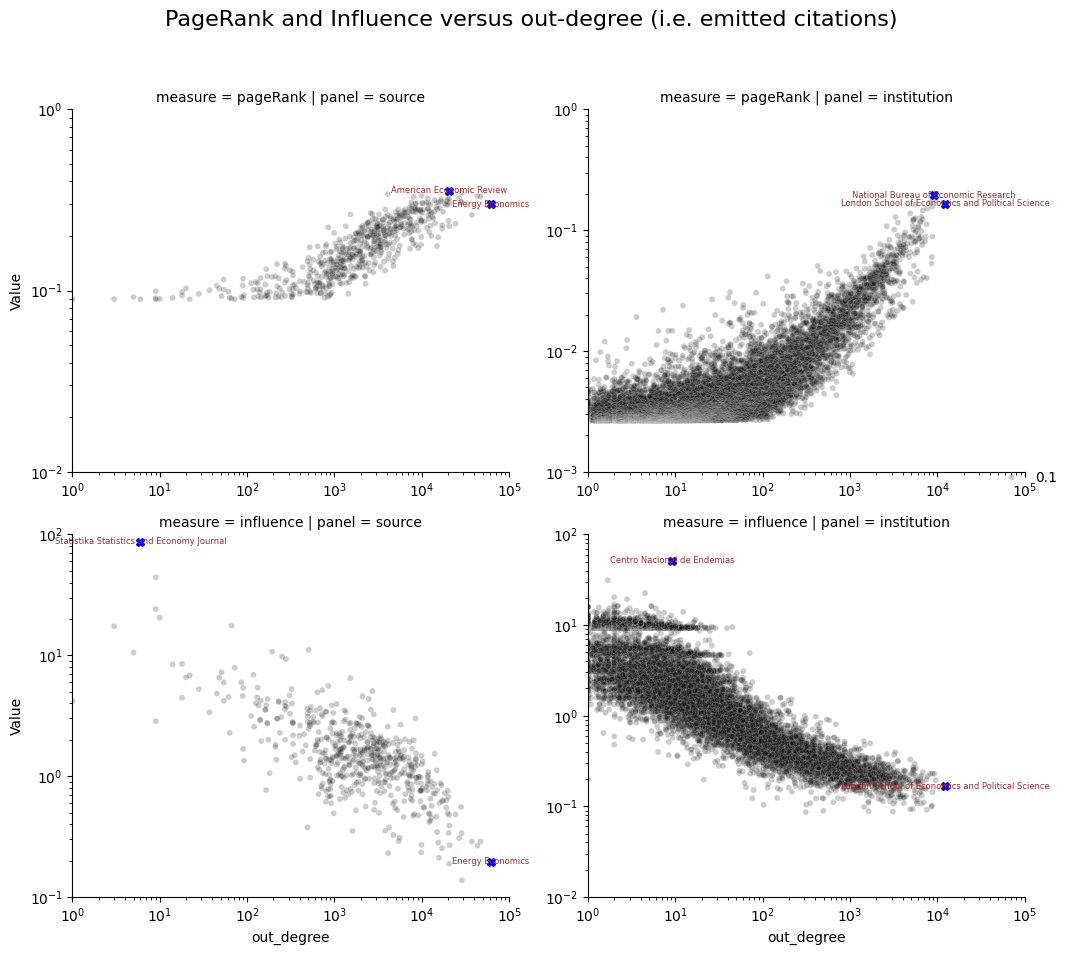

DONE!


In [18]:
if __name__ == "__main__":
    main()
    print("DONE!")